<a href="https://colab.research.google.com/github/rishiraj4/ML-Project/blob/main/ML_Project_Phase1_Rishi_Raj_N_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electrical Grid Stability (DataSet)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, svm, metrics

In [ ]:
egs = pd.read_csv("/content/Data_for_UCI_named.csv")
egs.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


**There are 12 input features and 1 target variable (stabf) that we are interested in as our project variables.
The stabf variable is non-numeric.**

In [ ]:
X = egs.iloc[:, :12].values
y = egs.iloc[:, 13].values

In [ ]:
print(X)

[[2.95906002 3.0798852  8.38102539 ... 0.85957811 0.88744492 0.95803399]
 [9.30409723 4.90252411 3.04754073 ... 0.86241408 0.56213905 0.78175991]
 [8.97170691 8.84842842 3.04647875 ... 0.76668866 0.83944402 0.10985324]
 ...
 [2.36403419 2.84203025 8.77639096 ... 0.98650532 0.14928646 0.14598403]
 [9.63151069 3.9943976  2.75707093 ... 0.58755755 0.88911835 0.81839133]
 [6.53052662 6.7817899  4.34969522 ... 0.50544105 0.37876093 0.94263083]]


In [ ]:
print(y)

['unstable' 'stable' 'unstable' ... 'stable' 'unstable' 'unstable']


In [ ]:
print(egs.columns)

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')


**Converting non-numeric data into numeric data**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y= le.fit_transform(y)
print(y)

[1 0 1 ... 0 1 1]


In [ ]:
print(le.classes_)

['stable' 'unstable']


**Splitting data into 75% training and 25% testing**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    stratify=y,
                                                    random_state=42)

In [ ]:
print(f'Numbers of samples and attributes: {X_train.shape}')

Numbers of samples and attributes: (7500, 12)


# **Logistic Regression for binary classification** (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_egs = LogisticRegression()
lr_egs.fit(X_train,y_train)

LogisticRegression()

Applying Standization Feature Scaling and checking the performance of the model

In [ ]:
from sklearn.preprocessing import StandardScaler

sfc = StandardScaler()
sfc.fit(X_train)

X_train_std = sfc.transform(X_train)
X_test_std = sfc.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_egs_std = LogisticRegression()
lr_egs_std.fit(X_train_std, y_train)

LogisticRegression()

In [ ]:
y_pred = lr_egs_std.predict(X_test_std)
print(y_pred)

[1 1 1 ... 1 1 1]


In [ ]:
print(y_test)

[1 1 1 ... 1 1 1]


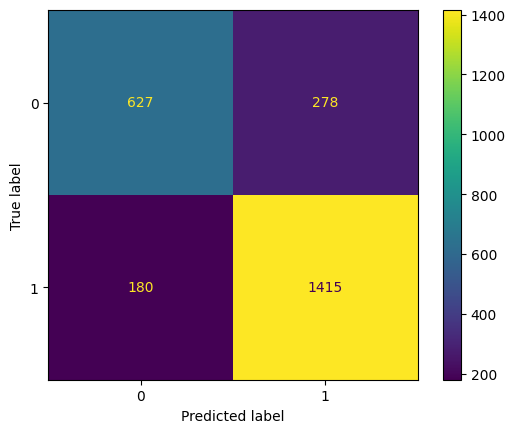

Precision: 0.836
Recall: 0.887
F1: 0.861


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

confMatrix = confusion_matrix(y_true = y_test, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()
F1_log = f1_score(y_true = y_test, y_pred = y_pred)

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = y_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = y_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = y_pred))

# **Support Vector Machines Classification**

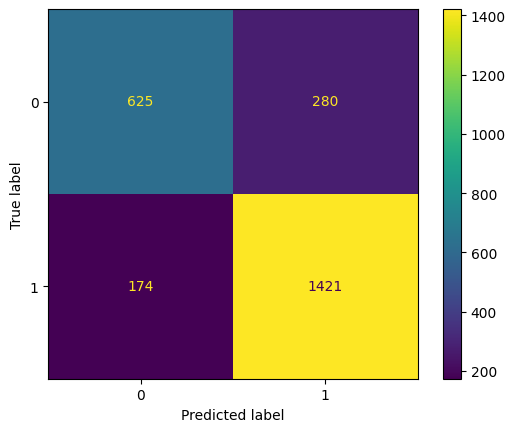

Precision: 0.835
Recall: 0.891
F1_Lin: 0.862


In [ ]:
#Fitting Linear SVM model using Standardized data

LSVM_std = svm.SVC(kernel='linear')
LSVM_std.fit(X_train_std, y_train)

predicted = LSVM_std.predict(X_test_std)

confMatrix = confusion_matrix(y_true = y_test, y_pred = predicted)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

F1_Lin = f1_score(y_true = y_test, y_pred = predicted)
print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = predicted))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = predicted))
print('F1_Lin: %.3f' % f1_score(y_true = y_test, y_pred = predicted))

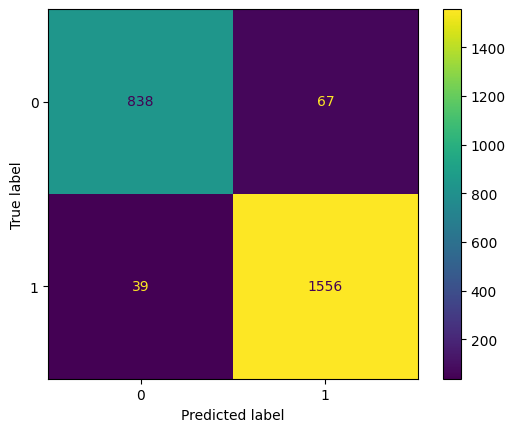

Precision: 0.959
Recall: 0.976
F1_rbf: 0.967


In [ ]:
#RBF SVM model using Standardized data
KSVM_std = svm.SVC(kernel='rbf')
KSVM_std.fit(X_train_std, y_train)

predicted = KSVM_std.predict(X_test_std)

confMatrix = confusion_matrix(y_true = y_test, y_pred = predicted)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

F1_rbf = f1_score(y_true = y_test, y_pred = predicted)
print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = predicted))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = predicted))
print('F1_rbf: %.3f' % f1_score(y_true = y_test, y_pred = predicted))

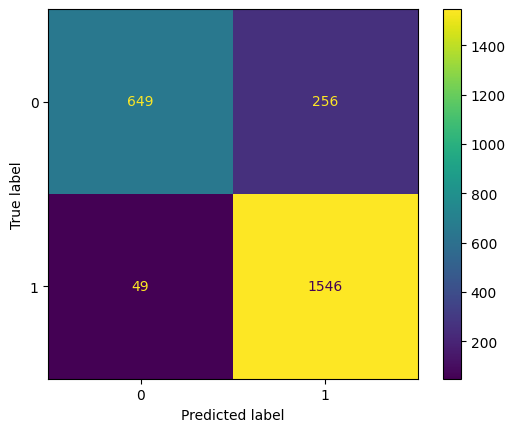

Precision: 0.858
Recall: 0.969
F1_poly: 0.910


In [ ]:
#Poly SVM model using Standardized data

Poly_std = svm.SVC(kernel='poly')
Poly_std.fit(X_train_std, y_train)

predicted = Poly_std.predict(X_test_std)

confMatrix = confusion_matrix(y_true = y_test, y_pred = predicted)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

F1_poly = f1_score(y_true = y_test, y_pred = predicted)
print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = predicted))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = predicted))
print('F1_poly: %.3f' % f1_score(y_true = y_test, y_pred = predicted))

# **Decision Tree Classification**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

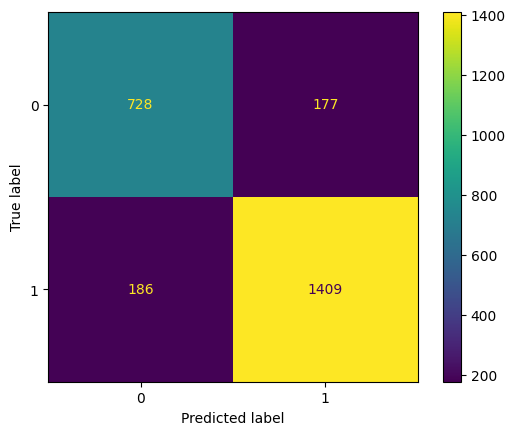

Precision: 0.888
Recall: 0.883
F1: 0.886


In [ ]:
y_pred = dtc.predict(X_test)

confMatrix = confusion_matrix(y_true = y_test, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()
F1_dtc = f1_score(y_true = y_test, y_pred = y_pred)

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = y_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = y_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = y_pred))

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

RandomForestClassifier()

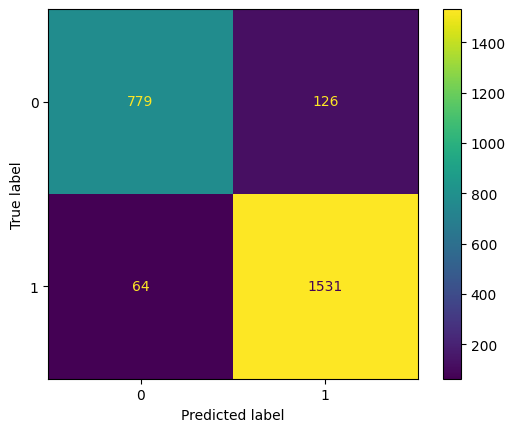

Precision: 0.924
Recall: 0.960
F1: 0.942


In [ ]:
y_pred = rfc.predict(X_test)

confMatrix = confusion_matrix(y_true = y_test, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()
F1_rfc = f1_score(y_true = y_test, y_pred = y_pred)

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = y_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = y_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = y_pred))

# **Boosting Methods**

In [ ]:
#Adaptive Boosting
from sklearn.ensemble import AdaBoostClassifier

ab_clf = AdaBoostClassifier()
ab_clf.fit(X_train, y_train)
y_pred = ab_clf.predict(X_test)

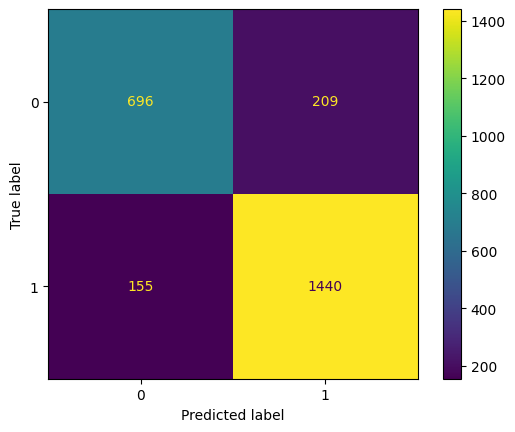

Precision: 0.873
Recall: 0.903
F1: 0.888


In [ ]:
confMatrix = confusion_matrix(y_true = y_test, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()
F1_ab = f1_score(y_true = y_test, y_pred = y_pred)

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = y_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = y_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = y_pred))

In [ ]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train, y_train)
y_pred = gb_clf.predict(X_test)

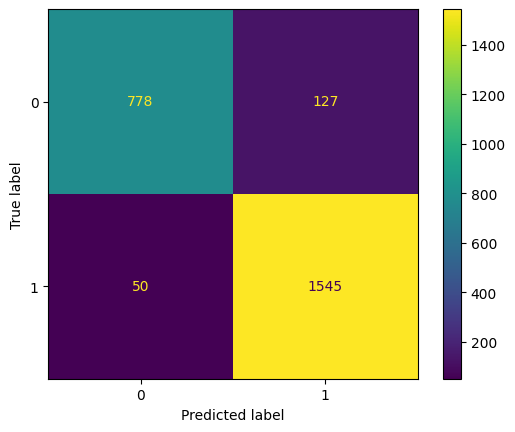

Precision: 0.924
Recall: 0.969
F1: 0.946


In [ ]:
confMatrix = confusion_matrix(y_true = y_test, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()
F1_gb = f1_score(y_true = y_test, y_pred = y_pred)

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = y_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = y_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = y_pred))

**Data visualisation of F1 score using a bar graph for each model**

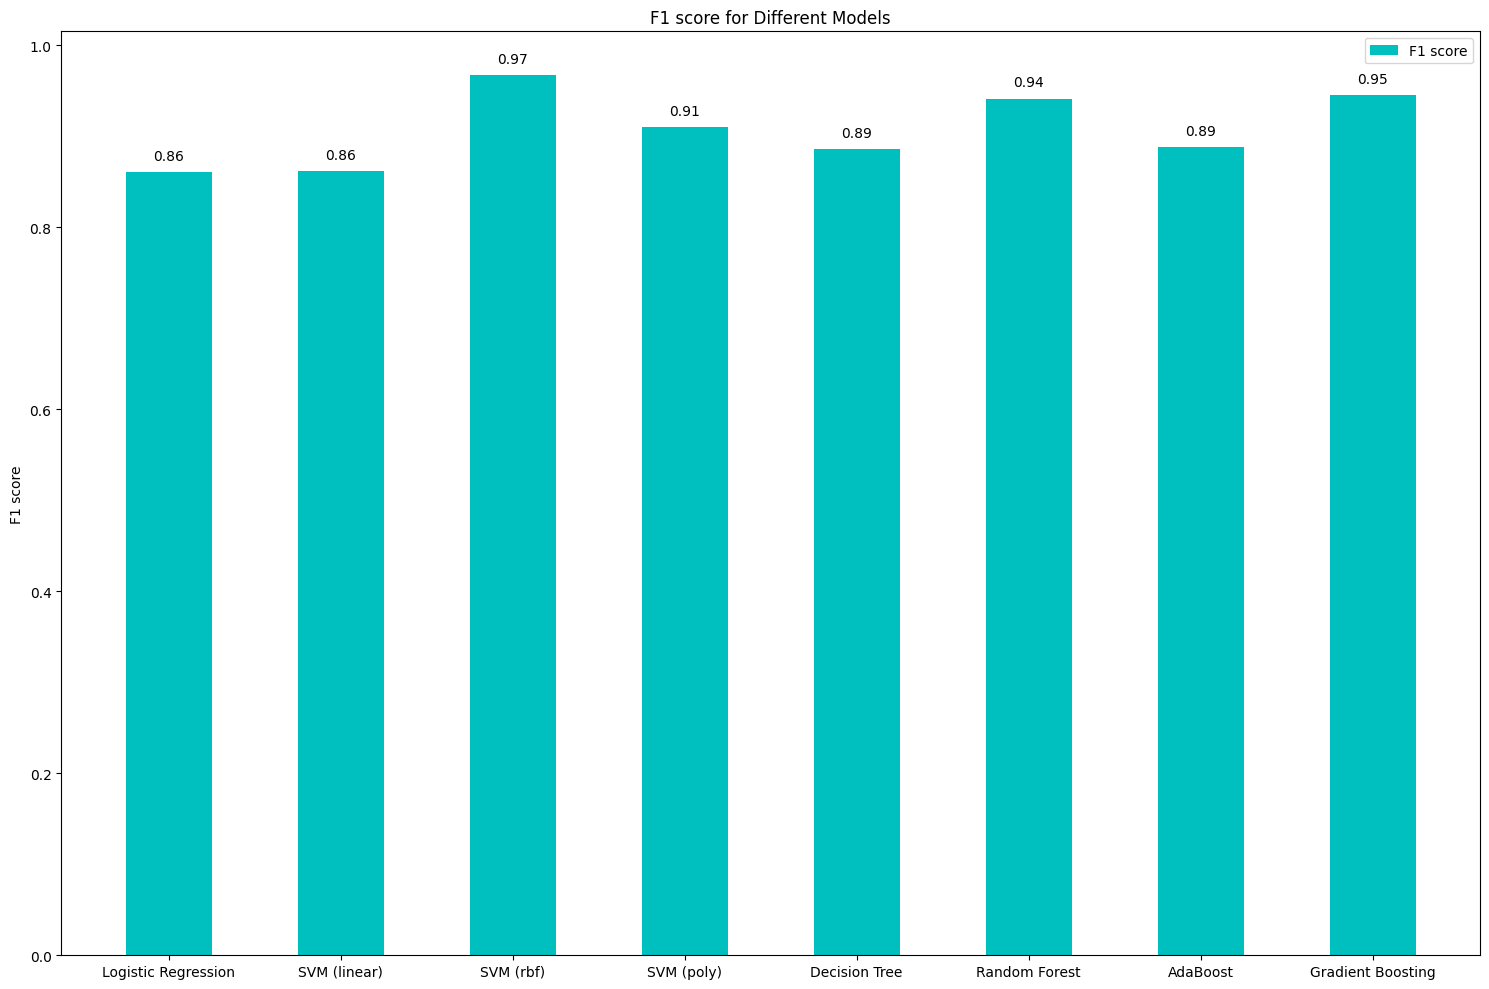

In [ ]:
#F1 score value for logistic and all the SVMs was determined using scaled data, while the other models were assessed using raw data.
models = [
    "Logistic Regression",
    "SVM (linear)",
    "SVM (rbf)",
    "SVM (poly)",
    "Decision Tree",
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting"]

F1 = [F1_log,F1_Lin,F1_rbf,F1_poly,F1_dtc,F1_rfc,F1_ab,F1_gb]

x = np.arange(len(models))  # Label locations
width = 0.5  # Width of the bars

fig, ax = plt.subplots(figsize=(15, 10))

# Bars for the data
bars = ax.bar(x, F1, width, label='F1 score', color='c')

# Adding labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

# Adding labels, title, and legend
ax.set_ylabel('F1 score')
ax.set_title('F1 score for Different Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Displaying the plot
plt.tight_layout()
plt.show()
